In [1]:
from rocketpy import Environment, Flight, Rocket, SolidMotor
import numpy
import datetime
import pandas as pd
import numpy as np
import json

In [2]:

%config InlineBackend.figure_formats = ['svg']
%matplotlib inline

In [3]:
env = Environment(latitude=-21.9430528, longitude=-48.9540861, elevation=478)

In [4]:
# Definir data/hora de lançamento (necessário para modelos dependentes do tempo)
import datetime
# Limpar qualquer configuração pré-existente de modelo atmosférico que possa causar re-execução automática
for attr in ("atmospheric_model_type", "atmospheric_model_file", "atmospheric_model_dict"):
    if hasattr(env, attr):
        try:
            setattr(env, attr, None)
        except Exception:
            pass
# usar data atual
env.set_date(datetime.datetime.now())
print('Launch date set to', env.datetime_date)


Launch date set to 2026-07-25 10:54:49.437306+00:00


In [5]:
# GFS  Global Forecast System
#env.set_atmospheric_model(type="Forecast", file="GFS")
env.set_atmospheric_model(type="standard_atmosphere")

In [6]:
# motor and rocket data 

motor_data = pd.read_csv("motor_data_pronto.csv")
motor_config  = pd.read_json("dedalo_motor.json" , typ="series")
rocket_data = pd.read_json("dedalo_data.json", typ="series")


In [7]:


# Now, use the NumPy array as the thrust source to initialize SolidMotor
Dedalo_motor = SolidMotor(
    thrust_source=motor_data, # Use the NumPy array
    dry_mass= motor_config["dry_mass"],
    dry_inertia=motor_config["dry_inertia"],
    nozzle_radius=motor_config["nozzle_radius"],
    grain_number=motor_config["grain_number"],
    grain_density=motor_config["grain_density"],
    grain_outer_radius=motor_config["grain_outer_radius"],
    grain_initial_inner_radius=motor_config["grain_initial_inner_radius"],
    grain_initial_height=motor_config["grain_initial_height"],
    grain_separation=motor_config["grain_separation"],
    grains_center_of_mass_position=motor_config["grains_center_of_mass_position"], 
    center_of_dry_mass_position=motor_config["center_of_dry_mass_position"], 
    nozzle_position=motor_config["nozzle_position"], 
    burn_time=motor_data['Time(s)'].iloc[-1],
    throat_radius=motor_config["throat_radius"],
    coordinate_system_orientation=motor_config["coordinate_system_orientation"],
)

print("\nSolidMotor initialized successfully!")


SolidMotor initialized successfully!


/home/barizon/flight-simulations/venv/lib/python3.12/site-packages/rocketpy/motors/motor.py:998: UserWarning: burn_time argument (0, np.float64(2.683)) is out of thrust source time range. Using thrust_source boundary times instead: (0.026, 2.683) s.
If you want to change the burn out time of the curve please use the 'reshape_thrust_curve' argument.
  warnings.warn(


/home/barizon/flight-simulations/venv/lib/python3.12/site-packages/rocketpy/mathutils/_calc/polation_1d.py:119: RuntimeWarning: divide by zero encountered in divide
  self._slopes = np.diff(self._y) / np.diff(self._x)


Rocket object created successfully!


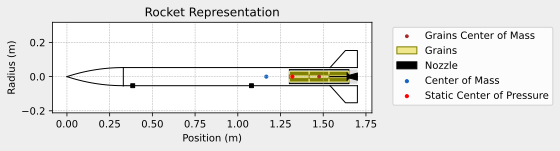

In [8]:
Dedalo_rocket = Rocket(
    radius = rocket_data["radius"],
    mass= rocket_data["mass"],
    power_off_drag="poweroff.csv",
    power_on_drag="poweron.csv",
    inertia= rocket_data["inertia"],
    center_of_mass_without_motor= rocket_data["center_of_mass_without_motor"],
    coordinate_system_orientation= rocket_data["coordinate_system_orientation"],
)

print("Rocket object created successfully!")
Dedalo_rocket.add_motor(Dedalo_motor, position=1.65)

nose_cone = Dedalo_rocket.add_nose(
    length=rocket_data["nose_length"], kind=rocket_data["nose_type"], position=rocket_data["nose_position"]
)


aletas = Dedalo_rocket.add_trapezoidal_fins(
    n = rocket_data["n_aletas"],
    root_chord= rocket_data["root_chord"],
    tip_chord= rocket_data["tip_chord"],
    span= rocket_data["span"],
    position= rocket_data["position"],
    cant_angle= rocket_data["cant_angle"]
)

rail_buttons = Dedalo_rocket.set_rail_buttons(
    upper_button_position=0.385,
    lower_button_position=1.08,
    angular_position=45,
)


main = Dedalo_rocket.add_parachute(
    name="main",
    cd_s=1.5,
    trigger="apogee",      # ejection altitude in meters
    sampling_rate=105,
    lag=1.5,
    radius=0.6,
    noise=(0, 8.3, 0.5),
)
Dedalo_rocket.draw()

In [9]:
Dedalo_rocket.info()


Inertia Details

Rocket Mass: 4.900 kg (without motor)
Rocket Dry Mass: 6.760 kg (with unloaded motor)
Rocket Loaded Mass: 8.467 kg
Rocket Structural Mass Ratio: 0.798
Rocket Inertia (with unloaded motor) 11: 1.429 kg*m2
Rocket Inertia (with unloaded motor) 22: 1.429 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.013 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.053 m
Rocket Frontal Area: 0.008825 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.122 m
Rocket Center of Dry Mass - Nozzle Exit: 0.611 m
Rocket Center of Dry Mass - Center of Propellant Mass: 0.387 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.078 m


Aerodynamics Lift Coefficient Derivatives

Nose Cone Lift Coefficient Derivative: 2.000/rad
Fins Lift Coefficient Derivative: 8.050/rad

Center of Pressure

Nose Co

In [13]:
Dedalo_flight = Flight(
    rocket=Dedalo_rocket, environment=env, rail_length=4, inclination=85, heading=0, verbose=True
    )

Current Simulation Time: 234.7715 s
>>> Simulation Completed at Time: 221.7392 s


/home/barizon/flight-simulations/venv/lib/python3.12/site-packages/rocketpy/mathutils/_calc/polation_1d.py:119: RuntimeWarning: invalid value encountered in divide
  self._slopes = np.diff(self._y) / np.diff(self._x)


In [14]:
Dedalo_flight.info()


Initial Conditions

Initial time: 0.000 s
Position - x: 0.00 m | y: 0.00 m | z: 478.00 m
Velocity - Vx: 0.00 m/s | Vy: 0.00 m/s | Vz: 0.00 m/s
Attitude (quaternions) - e0: -0.923 | e1: 0.040 | e2: 0.017 | e3: 0.382
Euler Angles - Spin φ : 315.00° | Nutation θ: -5.00° | Precession ψ: 0.00°
Angular Velocity - ω1: 0.00 rad/s | ω2: 0.00 rad/s | ω3: 0.00 rad/s
Initial Stability Margin: 1.439 c


Surface Wind Conditions

Frontal Surface Wind Speed: 0.00 m/s
Lateral Surface Wind Speed: 0.00 m/s


Launch Rail

Launch Rail Length: 4 m
Launch Rail Inclination: 85.00°
Launch Rail Heading: 0.00°


Rail Departure State

Rail Departure Time: 0.522 s
Rail Departure Velocity: 26.005 m/s
Rail Departure Stability Margin: 1.507 c
Rail Departure Angle of Attack: 0.000°
Rail Departure Thrust-Weight Ratio: 17.725
Rail Departure Reynolds Number: 1.818e+05


Burn out State

Burn out time: 2.683 s
Altitude at burn out: 884.622 m (ASL) | 406.622 m (AGL)
Rocket speed at burn out: 229.331 m/s
Freestream velocity

In [15]:
Dedalo_flight.plots

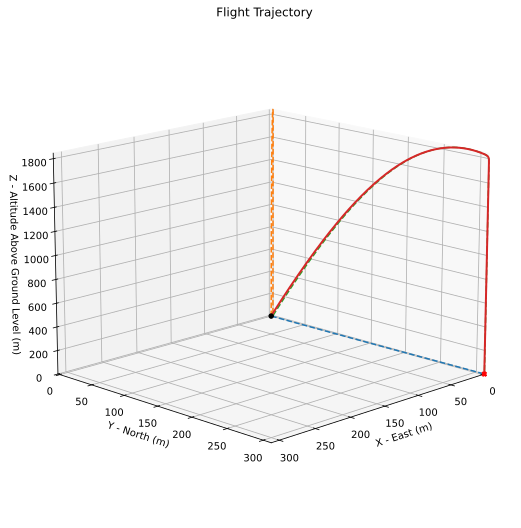

In [16]:
Dedalo_flight.plots.trajectory_3d()

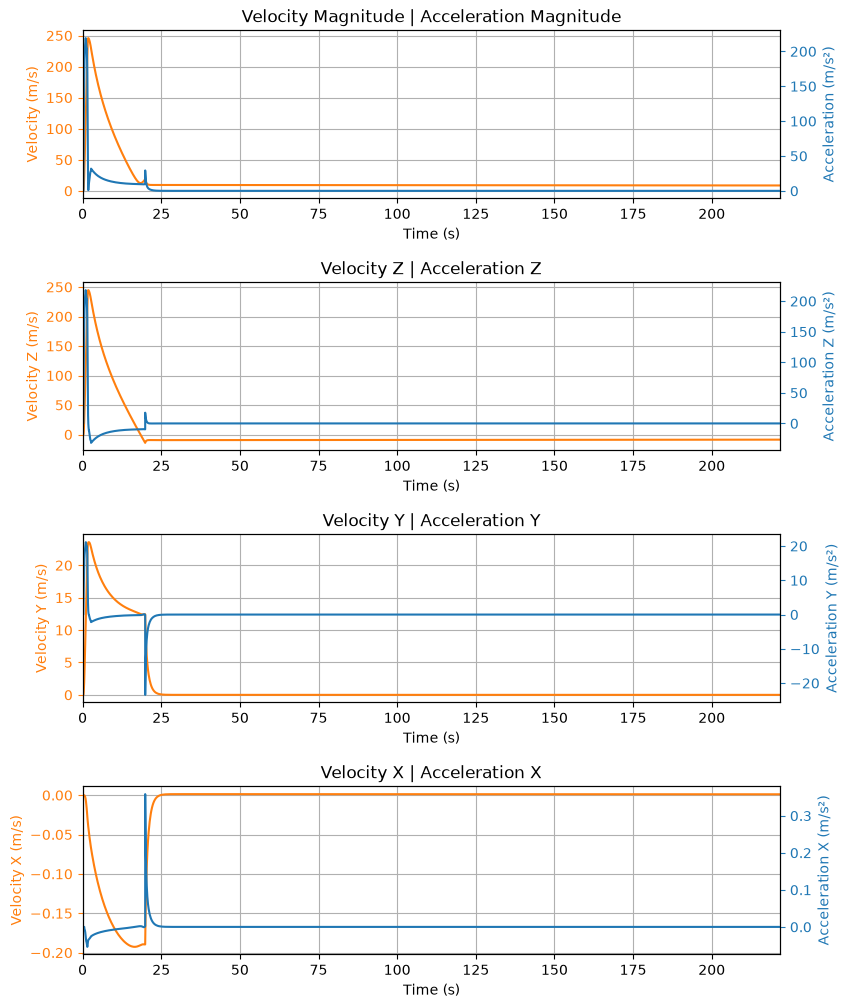

In [13]:
Dedalo_flight.plots.linear_kinematics_data()

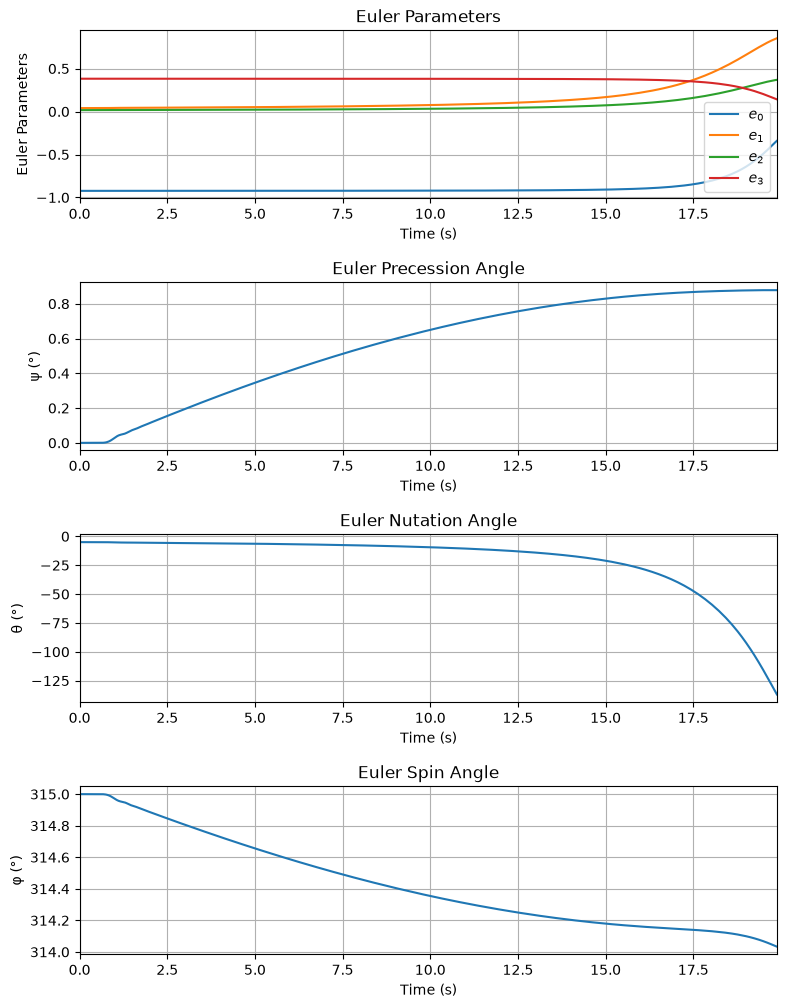

In [14]:
Dedalo_flight.plots.attitude_data()

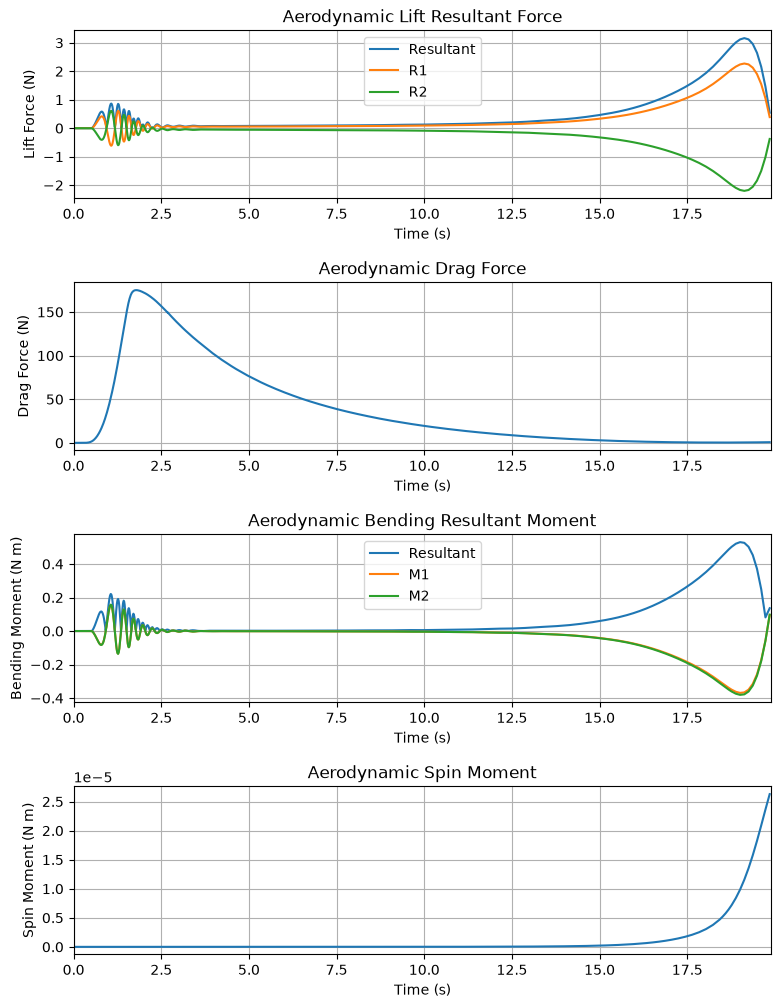

In [15]:
Dedalo_flight.plots.aerodynamic_forces()

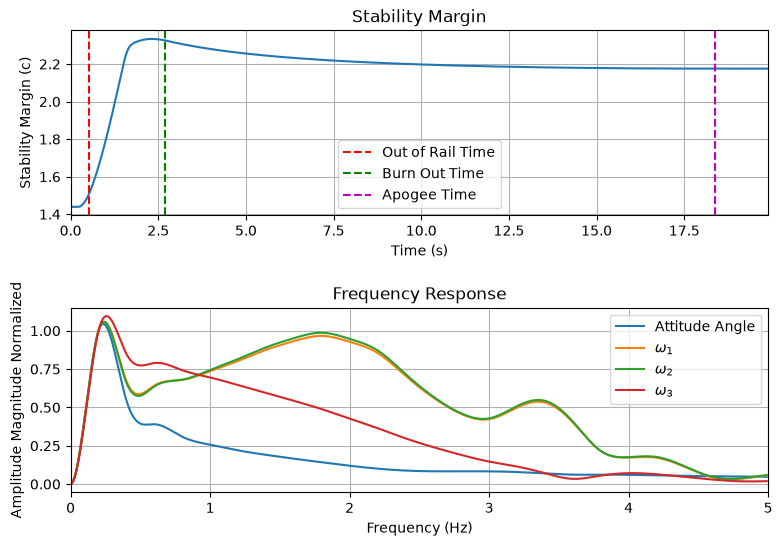

In [16]:
Dedalo_flight.plots.stability_and_control_data()



Trajectory 3d Plot



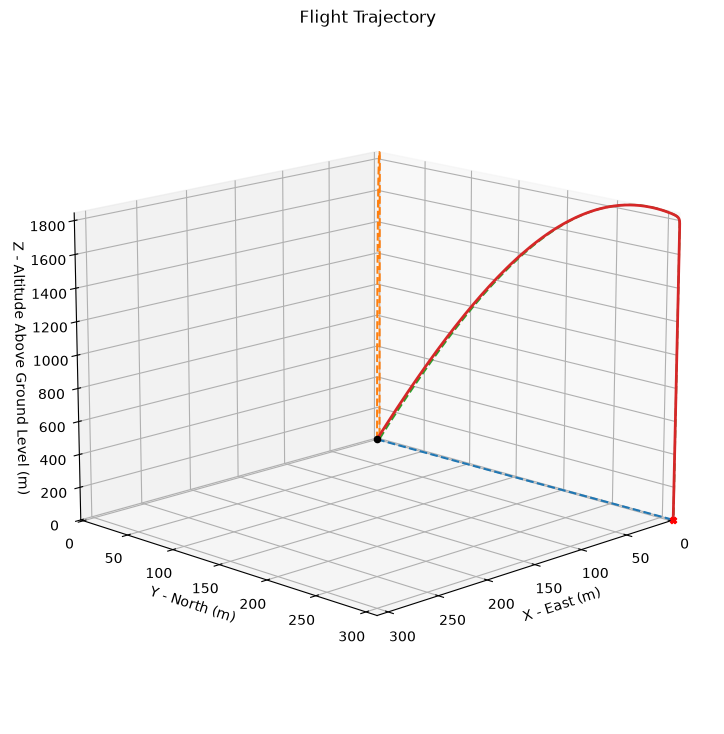



Trajectory Kinematic Plots



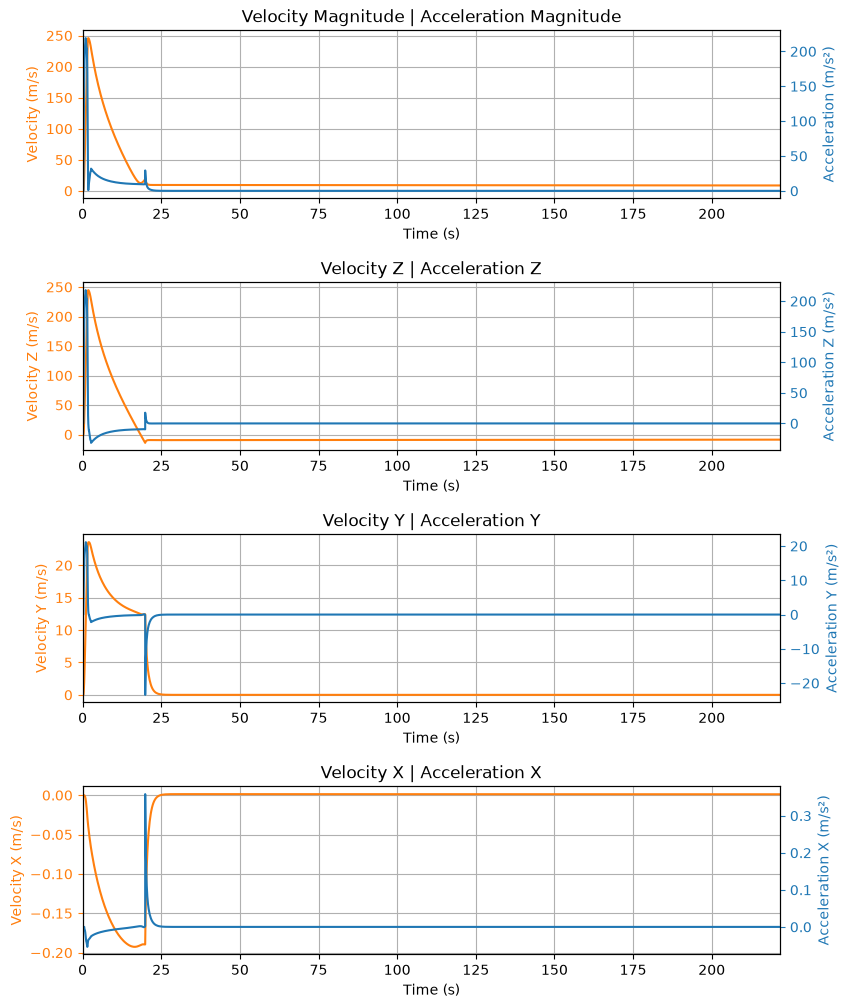



Angular Position Plots



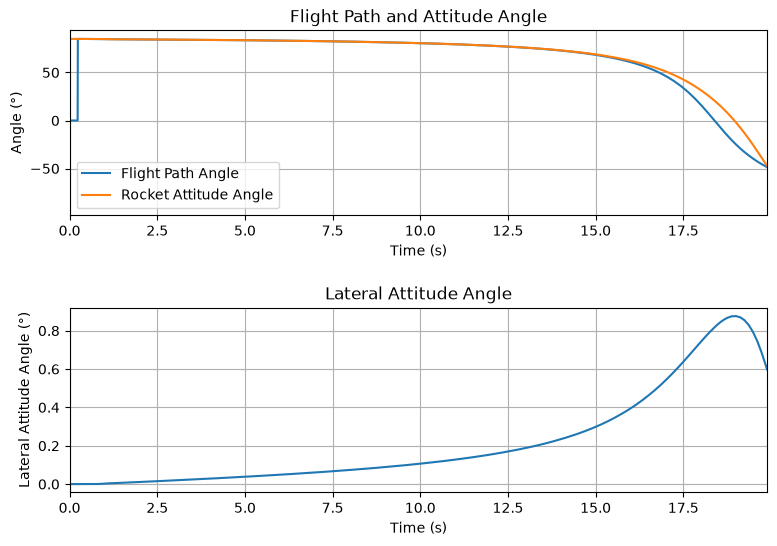



Path, Attitude and Lateral Attitude Angle Plots



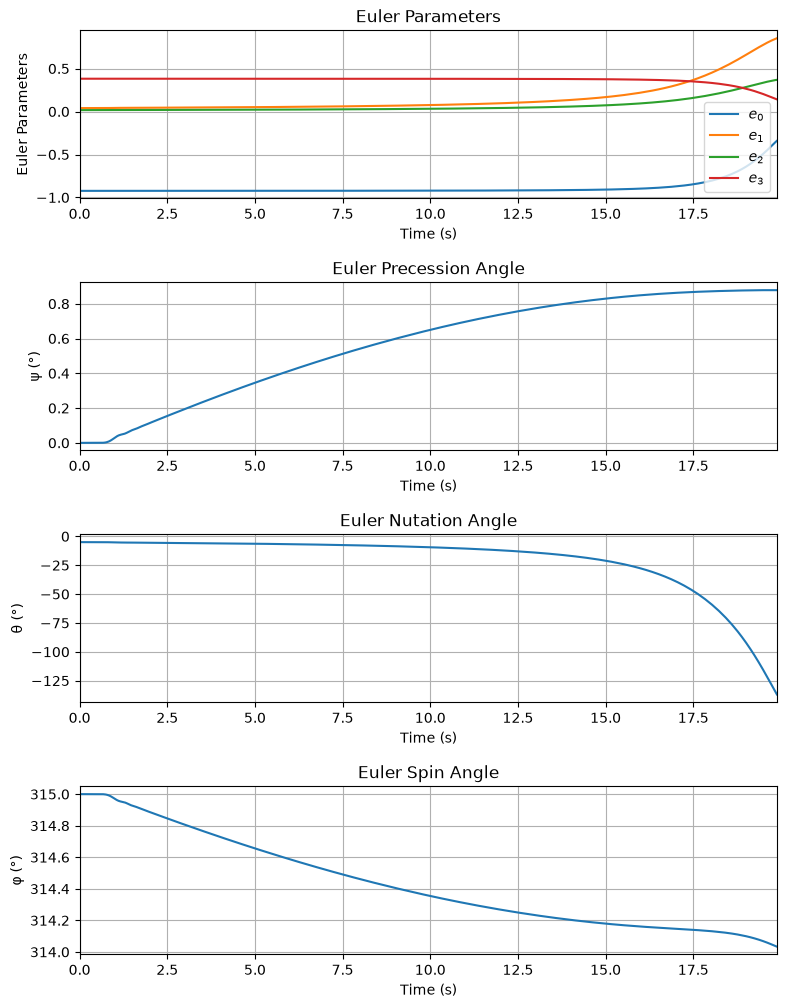



Trajectory Angular Velocity and Acceleration Plots



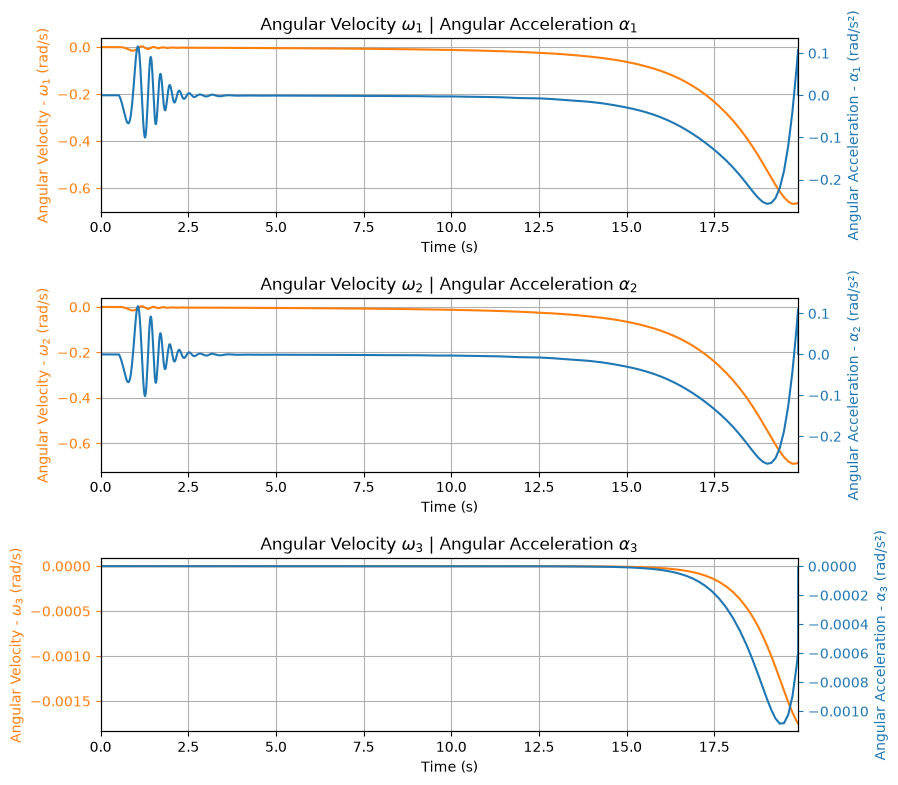



Aerodynamic Forces Plots



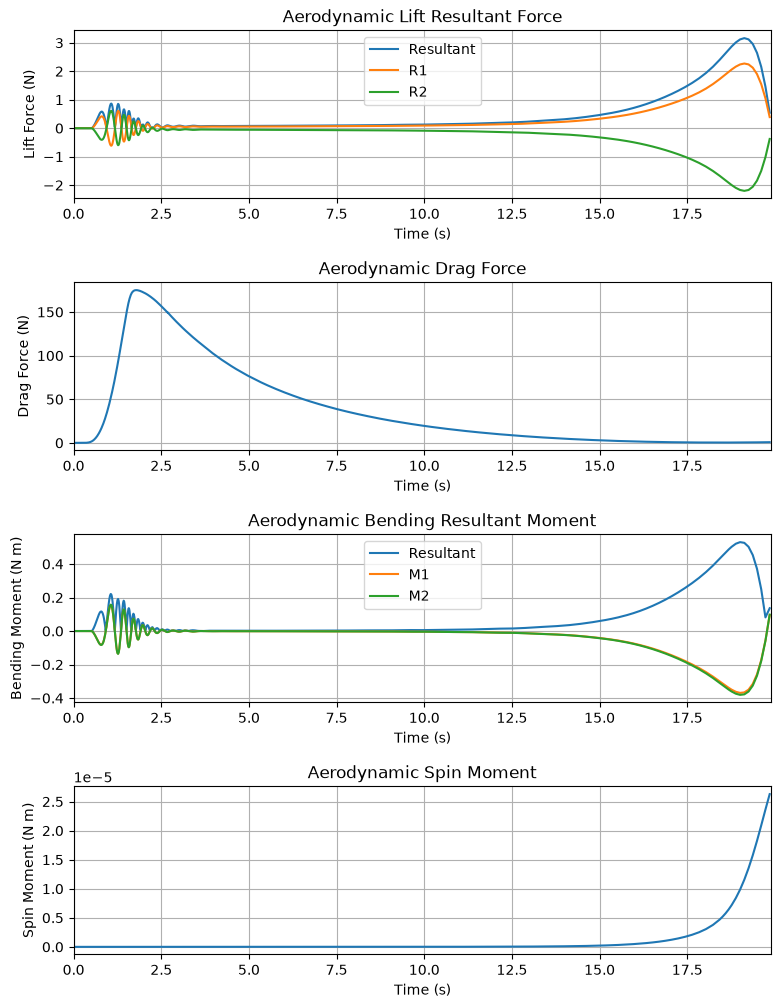

Rail button height not defined. Skipping bending moment plots.




Rail Buttons Bending Moments Plots



Rail Buttons Forces Plots



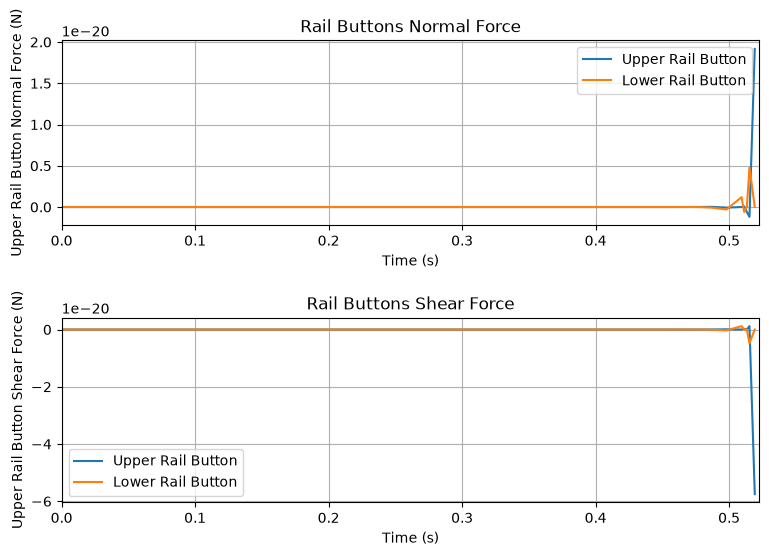



Trajectory Energy Plots



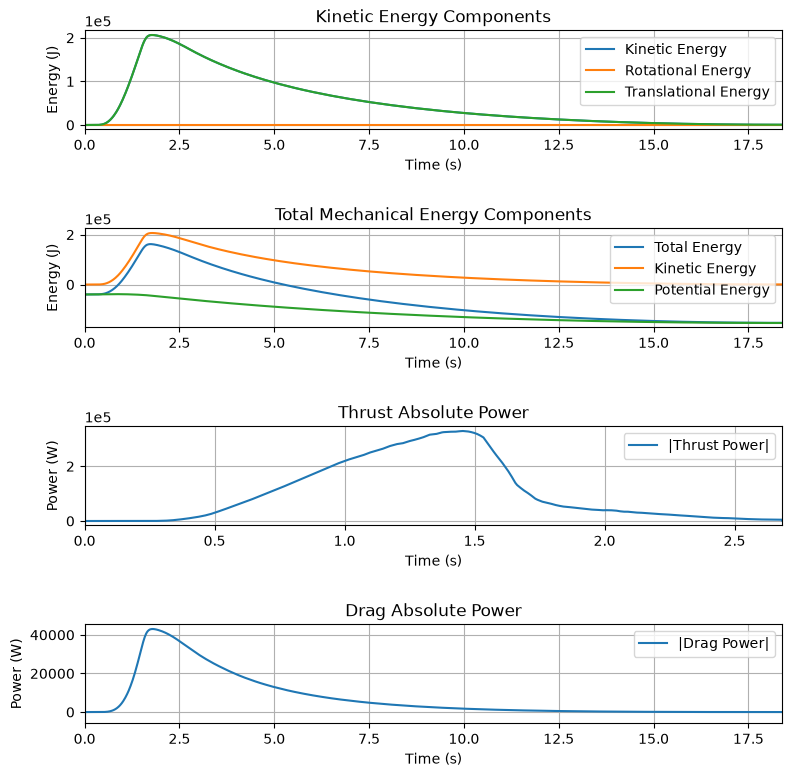



Trajectory Fluid Mechanics Plots



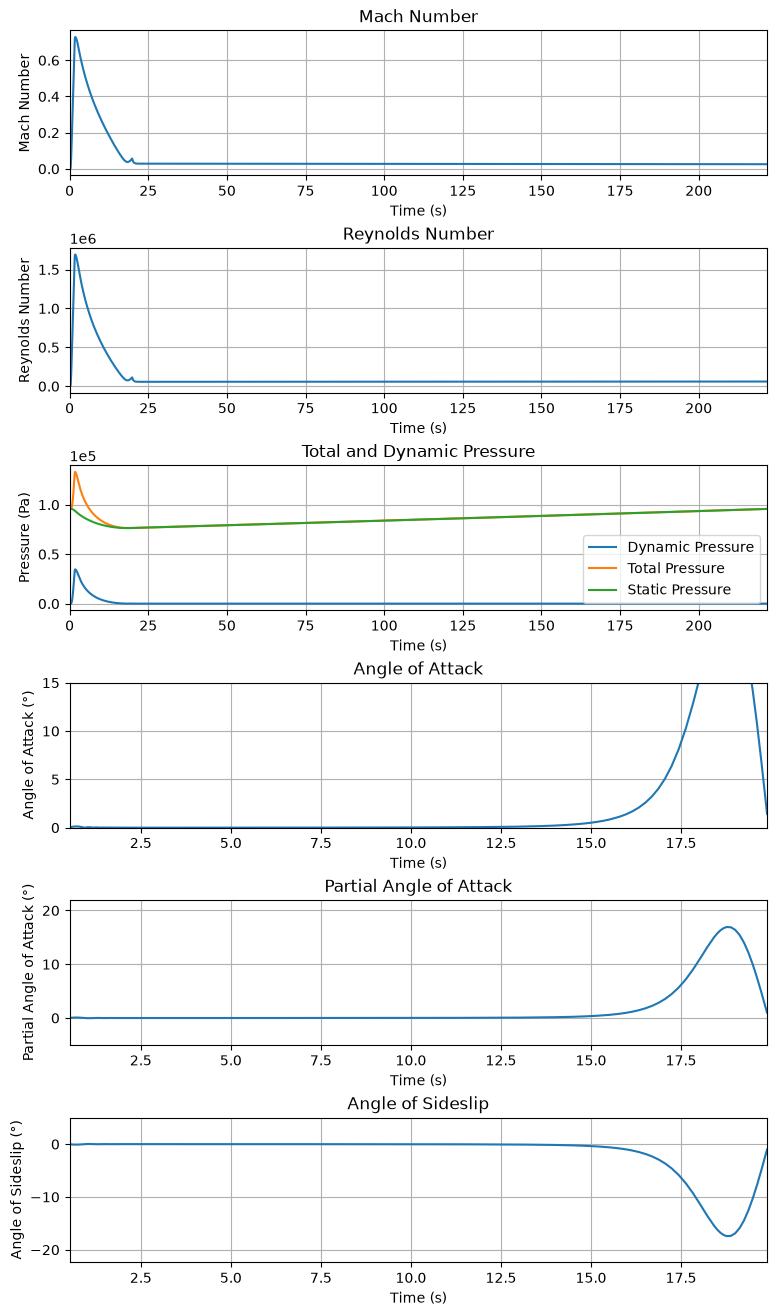



Trajectory Stability and Control Plots



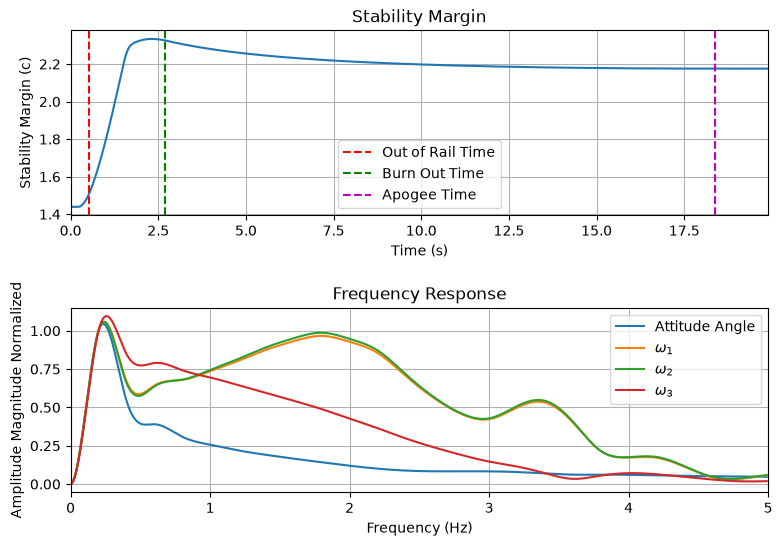



Rocket and Parachute Pressure Plots



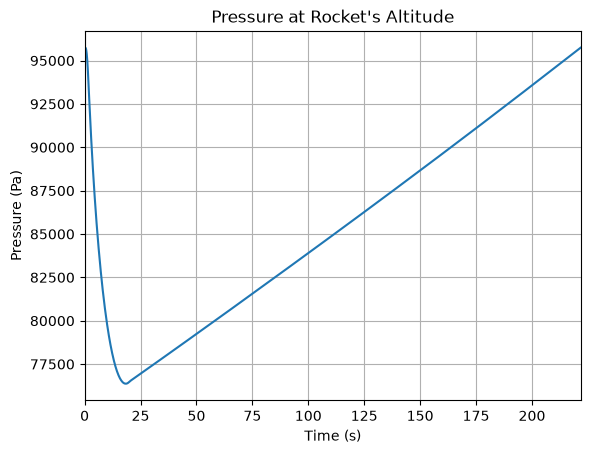

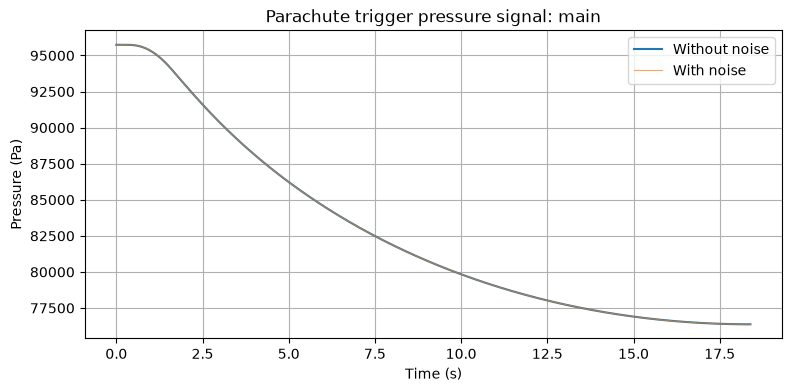

In [17]:
Dedalo_flight.plots.all()